In [102]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [103]:
df=pd.read_csv('Housing.csv')

In [104]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [105]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [106]:
new_df=df[['price','area','bedrooms','bathrooms']]

In [107]:
new_df.head()

,price,area,bedrooms,bathrooms
0,13300000,7420,4,2
1,12250000,8960,4,4
2,12250000,9960,3,2
3,12215000,7500,4,2
4,11410000,7420,4,1


In [108]:
# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

# Features & target
X = df.drop('price', axis=1)
y = df['price']

In [109]:
X # --> independent variable

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,7420,4,1,2,2,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,True,False,True,False,False,False,False,True
541,2400,3,1,1,0,False,False,False,False,False,False,True,False
542,3620,2,1,1,0,True,False,False,False,False,False,False,True
543,2910,3,1,1,0,False,False,False,False,False,False,False,False


In [110]:
y # --> dependent variable --> target

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


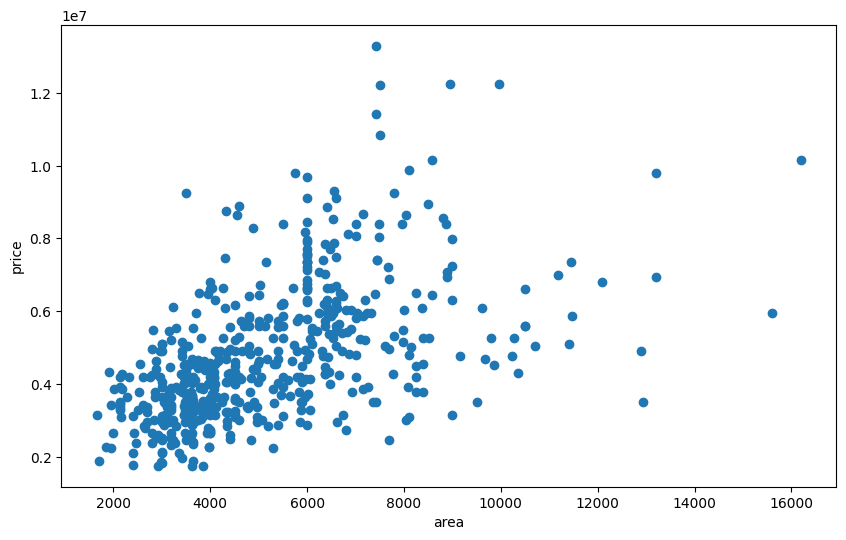

In [126]:
plt.figure(figsize=(10,6))
plt.scatter(new_df['area'],new_df['price'])
plt.xlabel('area')
plt.ylabel('price')
plt.show()

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
# Model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [128]:
print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


In [113]:
y_pred=model.predict(X_test)

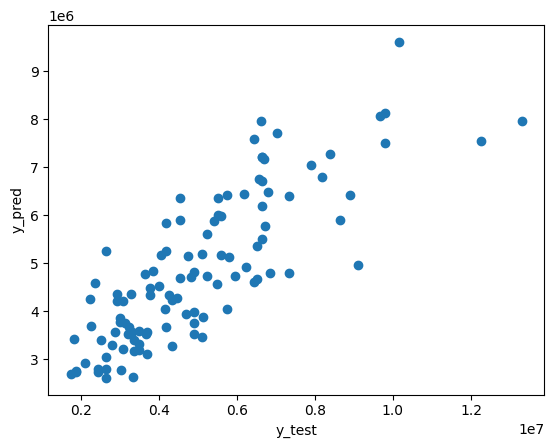

In [114]:
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.show()

In [115]:

# Calculate the coefficients and intercept
coefficients = model.coef_
intercept = model.intercept_
print("coefficients",coefficients)
print("intercept",intercept)


coefficients [ 2.35968805e+02  7.67787016e+04  1.09444479e+06  4.07476595e+05
  2.24841913e+05  3.67919948e+05  2.31610037e+05  3.90251176e+05
  6.84649885e+05  7.91426736e+05  6.29890565e+05 -1.26881818e+05
 -4.13645062e+05]
intercept 260032.35760741215


In [116]:
# Print the model equation
print("Model Equation:")
print(f"price = {coefficients[0]:.2f} * area + {coefficients[1]:.2f} * bedrooms + {coefficients[2]:.2f} * bathrooms + {intercept:.2f}")

Model Equation:
price = 235.97 * area + 76778.70 * bedrooms + 1094444.79 * bathrooms + 260032.36


In [117]:
import sklearn.metrics as metrics
import numpy as np

# Evaluation
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MSE: 1754318687330.6638
RMSE: 1324506.9600914386
MAE: 970043.4039201636
R2 Score: 0.6529242642153184


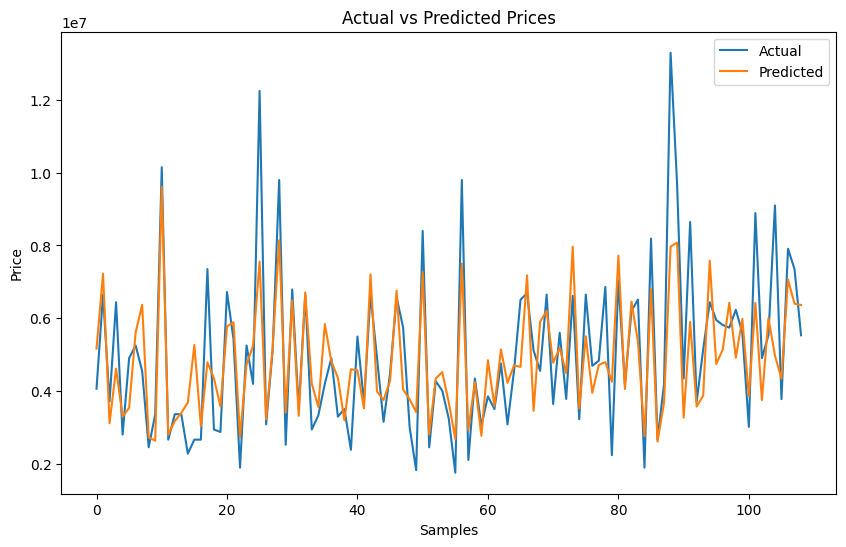

In [118]:

plt.figure(figsize=(10,6))

# Plot
plt.plot(range(len(y_test)), y_test.values, label='Actual')
plt.plot(range(len(y_pred)), y_pred, label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Prices")
plt.xlabel("Samples")
plt.ylabel("Price")

plt.show()

In [119]:
# Create a new dataframe
comparison_df = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': y_pred
})

# Reset index (important for clean alignment)
comparison_df.reset_index(drop=True, inplace=True)

comparison_df.head()

,Actual_Price,Predicted_Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06


In [120]:
comparison_df['Error'] = comparison_df['Actual_Price'] - comparison_df['Predicted_Price']

In [121]:
comparison_df['Absolute_Error'] = abs(comparison_df['Error'])

In [122]:
comparison_df.head()

,Actual_Price,Predicted_Price,Error,Absolute_Error
0,4060000,5.164654e+06,-1.104654e+06,1.104654e+06
1,6650000,7.224722e+06,-5.747223e+05,5.747223e+05
2,3710000,3.109863e+06,6.001368e+05,6.001368e+05
3,6440000,4.612075e+06,1.827925e+06,1.827925e+06
4,2800000,3.294646e+06,-4.946463e+05,4.946463e+05
